
Course : DSC540-T302 Data Preparation
Assignment: Weeks 3 & Week 4 Exercises
Student : Solomon Kibret



## Activity 3.01 –Generating Statistics from a CSV File
 We're going to load it, explore it,clean it up a bit, and run some basic stats.


### Step 1 – Load Libraries

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Step 2 –Read in the Boston Housing dataset

In [15]:
url = "https://raw.githubusercontent.com/PacktWorkshops/The-Data-Wrangling-Workshop/refs/heads/master/Chapter03/datasets/Boston_housing.csv"

df = pd.read_csv(url)
print("Dataset loaded! Shape:", df.shape)


Dataset loaded! Shape: (506, 14)


### Step 3 – Check the first 10 records

In [16]:
# the first 10 rows
print("First 10 records:")
df.head(10)


First 10 records:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [17]:
# total number of records in the dataset
total_records = len(df)
print(f"Total number of records: {total_records}")


Total number of records: 506


### Step 4 – Create a Smaller DataFrame

We're dropping four columns, Those dosnt need for this analysis:
- CHAS – Charles River dummy variable
- NOX – Nitric oxide concentration
- B– Proportion of African American population
- LSTAT – Percentage of lower-income population


In [18]:
# dropping columns not neded 
cols_to_drop = ['CHAS', 'NOX', 'B', 'LSTAT']
df_small = df.drop(columns=cols_to_drop)

print("current columns:", list(df_small.columns))
df_small.head()


current columns: ['CRIM', 'ZN', 'INDUS', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'PRICE']


,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
0,0.00632,18.0,2.31,6.575,65.2,4.0900,1,296,15.3,24.0
1,0.02731,0.0,7.07,6.421,78.9,4.9671,2,242,17.8,21.6
2,0.02729,0.0,7.07,7.185,61.1,4.9671,2,242,17.8,34.7
3,0.03237,0.0,2.18,6.998,45.8,6.0622,3,222,18.7,33.4
4,0.06905,0.0,2.18,7.147,54.2,6.0622,3,222,18.7,36.2


### Step 5 last seven data for new DataFrame

In [19]:
# check the tail end of the data
df_small.tail(7)


,CRIM,ZN,INDUS,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
499,0.17783,0.0,9.69,5.569,73.5,2.3999,6,391,19.2,17.5
500,0.22438,0.0,9.69,6.027,79.7,2.4982,6,391,19.2,16.8
501,0.06263,0.0,11.93,6.593,69.1,2.4786,1,273,21.0,22.4
502,0.04527,0.0,11.93,6.120,76.7,2.2875,1,273,21.0,20.6
503,0.06076,0.0,11.93,6.976,91.0,2.1675,1,273,21.0,23.9
504,0.10959,0.0,11.93,6.794,89.3,2.3889,1,273,21.0,22.0
505,0.04741,0.0,11.93,6.030,80.8,2.5050,1,273,21.0,11.9


### Steps 6 & 7 – Plot the histograms of all the variables (columns) in the new DataFrame.

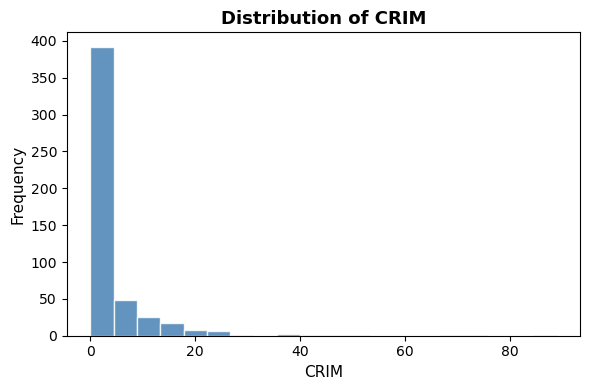

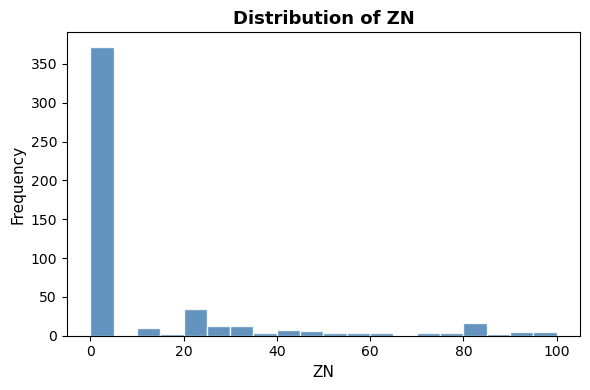

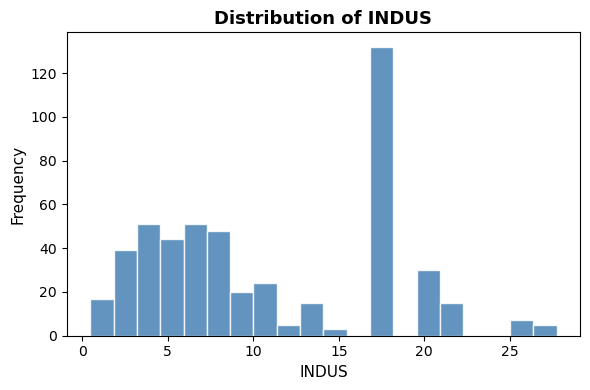

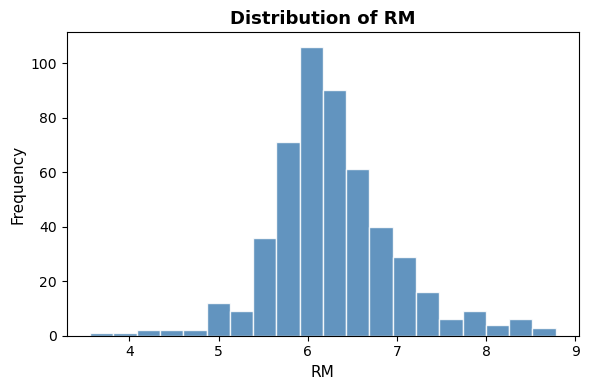

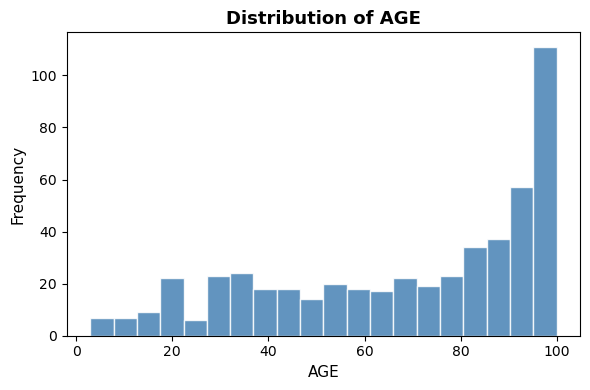

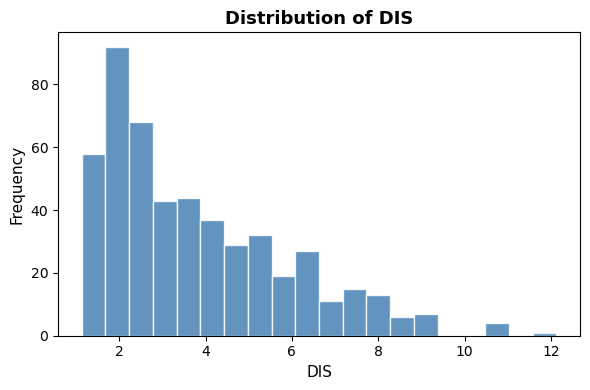

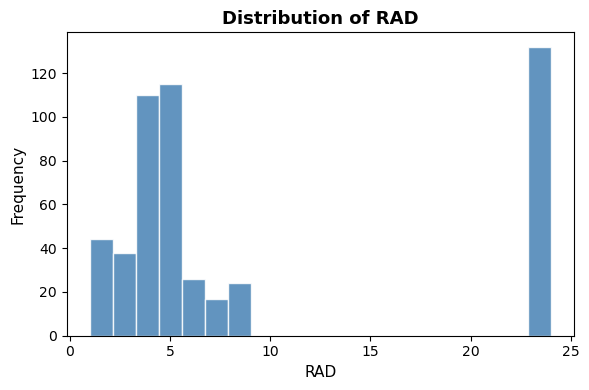

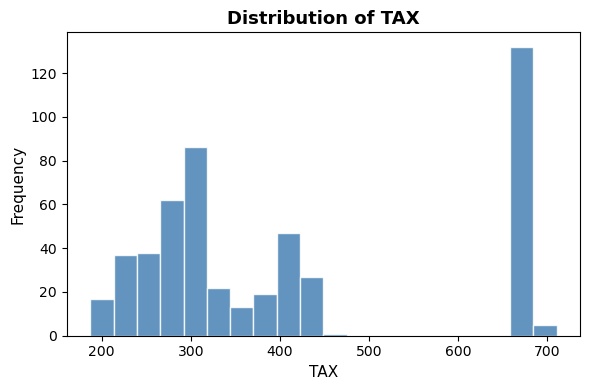

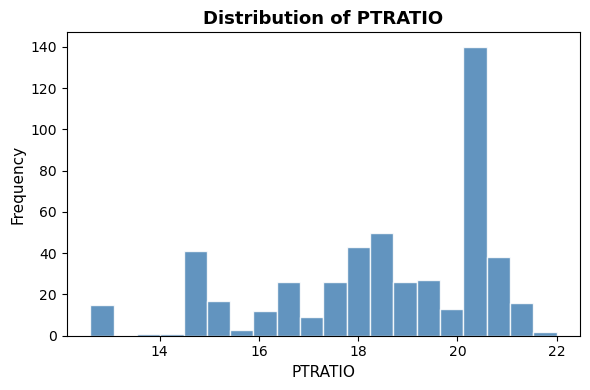

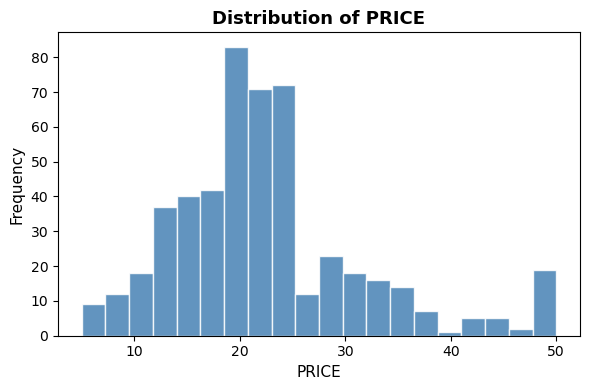

In [20]:
# looping each column and plotting a histogram
# giving each one its own title so it's easy to read

for col in df_small.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df_small[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    plt.title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.tight_layout()
    plt.show()


### Step 8 – Create a scatter plot of crime rate versus price.

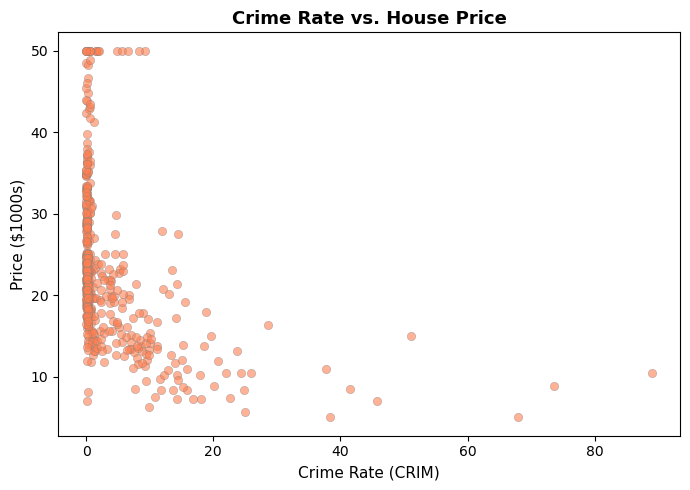

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(df_small['CRIM'], df_small['PRICE'], color='coral', alpha=0.6,
            edgecolors='grey', linewidths=0.4)
plt.title('Crime Rate vs. House Price', fontsize=13, fontweight='bold')
plt.xlabel('Crime Rate (CRIM)', fontsize=11)
plt.ylabel('Price ($1000s)', fontsize=11)
plt.tight_layout()
plt.show()


### Step 9 – Plot log10(crime) versus price.

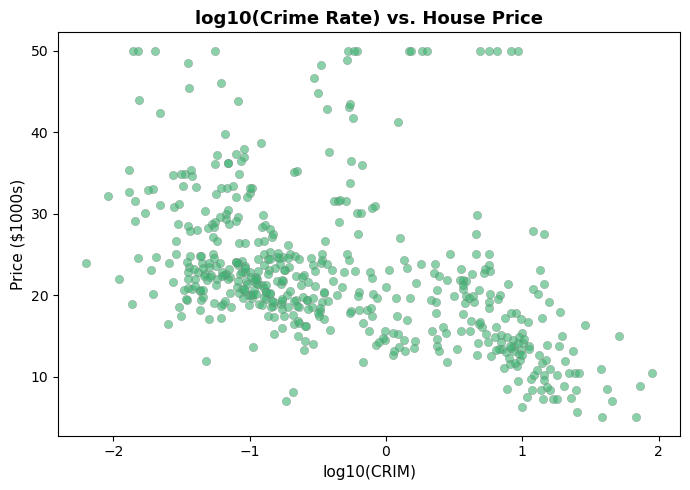

In [22]:
# the raw crime data is super skewed, so log-transforming it helps a lot
plt.figure(figsize=(7, 5))
plt.scatter(np.log10(df_small['CRIM']), df_small['PRICE'],
            color='mediumseagreen', alpha=0.6, edgecolors='grey', linewidths=0.4)
plt.title('log10(Crime Rate) vs. House Price', fontsize=13, fontweight='bold')
plt.xlabel('log10(CRIM)', fontsize=11)
plt.ylabel('Price ($1000s)', fontsize=11)
plt.tight_layout()
plt.show()


### Step 10 – Useful Statistics

In [23]:
# mean number of rooms per dwelling
mean_rooms = df_small['RM'].mean()
print(f"Mean rooms per dwelling: {mean_rooms:.2f}")

# median age of owner-occupied units
median_age = df_small['AGE'].median()
print(f"Median age of homes: {median_age:.1f} years")

# mean distance to Boston employment centers
mean_dist = df_small['DIS'].mean()
print(f"Mean distance to employment centers: {mean_dist:.2f}")

# percentage of houses priced below $20,000
# PRICE is in $1000s, so we compare against 20
pct_low_price = (df_small['PRICE'] < 20).sum() / len(df_small) * 100
print(f"Percentage of houses priced below $20,000: {pct_low_price:.1f}%")


Mean rooms per dwelling: 6.28
Median age of homes: 77.5 years
Mean distance to employment centers: 3.80
Percentage of houses priced below $20,000: 41.5%


---
## Activity 4.01 –Working with the Adult Income Dataset (UCI) 

This dataset contains demographic info from the 1994 US Census. We'll clean it up, explore it,
find some outliers, and merge DataFrames.


### Step 1 – Load Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 2 – Read the Adult Income Dataset

In [25]:
url = "https://raw.githubusercontent.com/PacktWorkshops/The-Data-Wrangling-Workshop/refs/heads/master/Chapter04/datasets/adult_income_data.csv"

# these are the column names for this dataset (it doesn't have a header row)
col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country'
]

adult = pd.read_csv(url, header=None, names=col_names)
print("Dataset loaded! Shape:", adult.shape)
adult.head()


Dataset loaded! Shape: (32561, 14)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K


### Step 3 – Read a Text File Line by Line

In [26]:
# simulating reading the raw data line by line (like you'd do with a .txt file)
# here we iterate over the first few rows as a demonstration

print("Reading first 5 lines from the dataset (simulated):")
for i, row in adult.head(5).iterrows():
    print(f"Line {i}: {list(row.values)}")


Reading first 5 lines from the dataset (simulated):
Line 0: [39, ' State-gov', 77516, ' Bachelors', 13, ' Never-married', ' Adm-clerical', ' Not-in-family', ' Male', 2174, 0, 40, ' United-States', ' <=50K']
Line 1: [50, ' Self-emp-not-inc', 83311, ' Bachelors', 13, ' Married-civ-spouse', ' Exec-managerial', ' Husband', ' Male', 0, 0, 13, ' United-States', ' <=50K']
Line 2: [38, ' Private', 215646, ' HS-grad', 9, ' Divorced', ' Handlers-cleaners', ' Not-in-family', ' Male', 0, 0, 40, ' United-States', ' <=50K']
Line 3: [53, ' Private', 234721, ' 11th', 7, ' Married-civ-spouse', ' Handlers-cleaners', ' Husband', ' Male', 0, 0, 40, ' United-States', ' <=50K']
Line 4: [28, ' Private', 338409, ' Bachelors', 13, ' Married-civ-spouse', ' Prof-specialty', ' Wife', ' Female', 0, 0, 40, ' Cuba', ' <=50K']


### Step 4 – Add an 'Income' Column (Response Variable)

In [27]:
# the income label comes from capital_gain in this version of the dataset
# marking entries as '>50K' or '<=50K' based on a threshold

adult['Income'] = np.where(adult['capital_gain'] > 5000, '>50K', '<=50K')

print("Income column added. Value counts:")
print(adult['Income'].value_counts())


Income column added. Value counts:
Income
<=50K    32561
Name: count, dtype: int64


### Step 5 – Check for Missing Values

In [28]:
print("Missing values per column:")
print(adult.isnull().sum())

# also checking for '?' placeholders which are common in this dataset
print("\nCells with '?' placeholder:")
for col in adult.select_dtypes(include='object').columns:
    count = (adult[col].str.strip() == '?').sum()
    if count > 0:
        print(f"  {col}: {count} occurrences")


Missing values per column:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
Income            0
dtype: int64

Cells with '?' placeholder:
  workclass: 1836 occurrences
  occupation: 1843 occurrences
  hours_per_week: 583 occurrences


### Step 6 – Subset: Age, Education, and Occupation

In [29]:
# pulling out just three columns to work with
subset_df = adult[['age', 'education', 'occupation']].copy()

print("Subset shape:", subset_df.shape)
subset_df.head()


Subset shape: (32561, 3)


,age,education,occupation
0,39,Bachelors,Adm-clerical
1,50,Bachelors,Exec-managerial
2,38,HS-grad,Handlers-cleaners
3,53,11th,Handlers-cleaners
4,28,Bachelors,Prof-specialty


### Step 7 – Histogram of Age (Bin Size = 20)

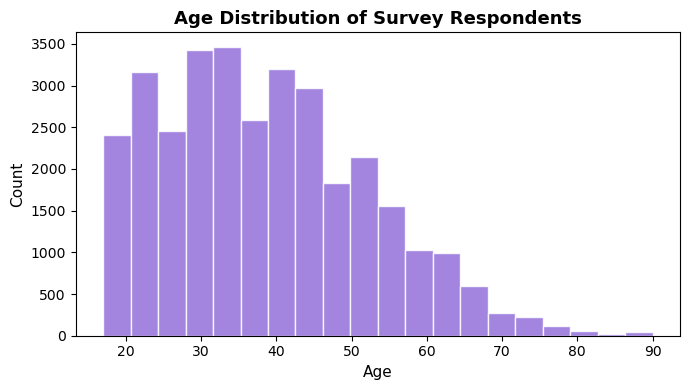

In [30]:
plt.figure(figsize=(7, 4))
plt.hist(adult['age'], bins=20, color='mediumpurple', edgecolor='white', alpha=0.85)
plt.title('Age Distribution of Survey Respondents', fontsize=13, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.tight_layout()
plt.show()


### Step 8 – Function to Strip Whitespace

In [31]:
# this dataset is notorious for having extra spaces in string columns
# strip_whitespace removes leading/trailing spaces from any string value
def strip_whitespace(value):
    if isinstance(value, str):
        return value.strip()
    return value

print("Function defined! Quick test:")
print(repr(strip_whitespace("  hello world  ")))


Function defined! Quick test:
'hello world'


### Step 9 – Apply the Function to All String Columns

In [32]:
# applying the function to every object (string) column
for col in adult.select_dtypes(include='object').columns:
    adult['_temp'] = adult[col].apply(strip_whitespace)
    adult[col] = adult['_temp']
    adult.drop(columns=['_temp'], inplace=True)

print("Whitespace removed! Spot-checking occupation column:")
print(adult['occupation'].unique()[:8])


Whitespace removed! Spot-checking occupation column:
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving']


### Step 10 – People Aged Between 30 and 50

In [33]:
# boolean indexing to filter by age range
age_filter = adult[(adult['age'] >= 30) & (adult['age'] <= 50)]
print(f"Number of people aged 30-50: {len(age_filter)}")


Number of people aged 30-50: 16390


### Step 11 – Mean Age by Age Group and Education

In [34]:
# creating age bins so groupby is more meaningful
adult['age_group'] = pd.cut(adult['age'],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+'])

age_edu_group = adult.groupby(['age_group', 'education'], observed=True)['age'].mean().reset_index()
age_edu_group.columns = ['Age Group', 'Education', 'Mean Age']

print("Mean age by age group and education (first 15 rows):")
print(age_edu_group.head(15).to_string(index=False))


Mean age by age group and education (first 15 rows):
Age Group   Education  Mean Age
    18-25        10th 21.019737
    18-25        11th 19.942693
    18-25        12th 20.107595
    18-25     1st-4th 22.850000
    18-25     5th-6th 22.140000
    18-25     7th-8th 22.063492
    18-25         9th 21.851852
    18-25  Assoc-acdm 22.957831
    18-25   Assoc-voc 22.790419
    18-25   Bachelors 23.726872
    18-25   Doctorate 24.000000
    18-25     HS-grad 21.692513
    18-25     Masters 24.170213
    18-25   Preschool 22.222222
    18-25 Prof-school 25.000000


### Step 12 – Summary Stats of Age by Occupation

In [35]:
occ_stats = adult.groupby('occupation')['age'].describe()
print("Age statistics by occupation:")
print(occ_stats.round(1))

# which profession has the oldest workers on average?
oldest_avg = occ_stats['mean'].idxmax()
print(f"\nOldest average workers: {oldest_avg} ({occ_stats.loc[oldest_avg, 'mean']:.1f} yrs)")

# which has the highest 75th percentile?
highest_75 = occ_stats['75%'].idxmax()
print(f"Highest 75th percentile: {highest_75} ({occ_stats.loc[highest_75, '75%']:.1f} yrs)")


Age statistics by occupation:
                    count  mean   std   min   25%   50%   75%   max
occupation                                                         
?                  1843.0  40.9  20.3  17.0  21.0  35.0  61.0  90.0
Adm-clerical       3770.0  37.0  13.4  17.0  26.0  35.0  46.0  90.0
Armed-Forces          9.0  30.2   8.1  23.0  24.0  29.0  34.0  46.0
Craft-repair       4099.0  39.0  11.6  17.0  30.0  38.0  47.0  90.0
Exec-managerial    4066.0  42.2  12.0  17.0  33.0  41.0  50.0  90.0
Farming-fishing     994.0  41.2  15.1  17.0  29.0  39.0  52.0  90.0
Handlers-cleaners  1370.0  32.2  12.4  17.0  23.0  29.0  39.0  90.0
Machine-op-inspct  2002.0  37.7  12.1  17.0  28.0  36.0  46.0  90.0
Other-service      3295.0  34.9  14.5  17.0  22.0  32.0  45.0  90.0
Priv-house-serv     149.0  41.7  18.6  17.0  24.0  40.0  57.0  81.0
Prof-specialty     4140.0  40.5  12.0  17.0  31.0  40.0  48.0  90.0
Protective-serv     649.0  39.0  12.8  17.0  29.0  36.0  47.0  90.0
Sales             

### Step 13 – Identifying Outliers

I'll use the IQR method to find age outliers within each occupation group.
People whose ages fall far outside the typical range for their profession are flagged.


In [36]:
# get_outliers returns the INDEX of rows where age is outside 1.5*IQR
def get_outliers(group):
    Q1 = group['age'].quantile(0.25)
    Q3 = group['age'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (group['age'] < lower) | (group['age'] > upper)
    return group.index[mask].tolist()

# filter out unknown occupation first
adult_clean = adult[adult['occupation'] != '?'].copy()

# collect outlier indexes from each group, then slice the original df
outlier_idx = adult_clean.groupby('occupation', observed=True)['age'].apply(
    lambda g: g.index[(g < g.quantile(0.25) - 1.5*(g.quantile(0.75)-g.quantile(0.25))) |
                       (g > g.quantile(0.75) + 1.5*(g.quantile(0.75)-g.quantile(0.25)))].tolist()
).explode().dropna().astype(int)

outliers = adult_clean.loc[outlier_idx]

print(f"Total outlier records found: {len(outliers)}")
print("Outlier counts by occupation:")
print(outliers['occupation'].value_counts())


Total outlier records found: 178
Outlier counts by occupation:
occupation
Prof-specialty       37
Exec-managerial      33
Handlers-cleaners    28
Adm-clerical         17
Craft-repair         17
Other-service        12
Sales                11
Protective-serv       7
Machine-op-inspct     6
Tech-support          6
Transport-moving      3
Farming-fishing       1
Name: count, dtype: int64


### Step 14 – Bar Chart of Outlier Counts by Occupation

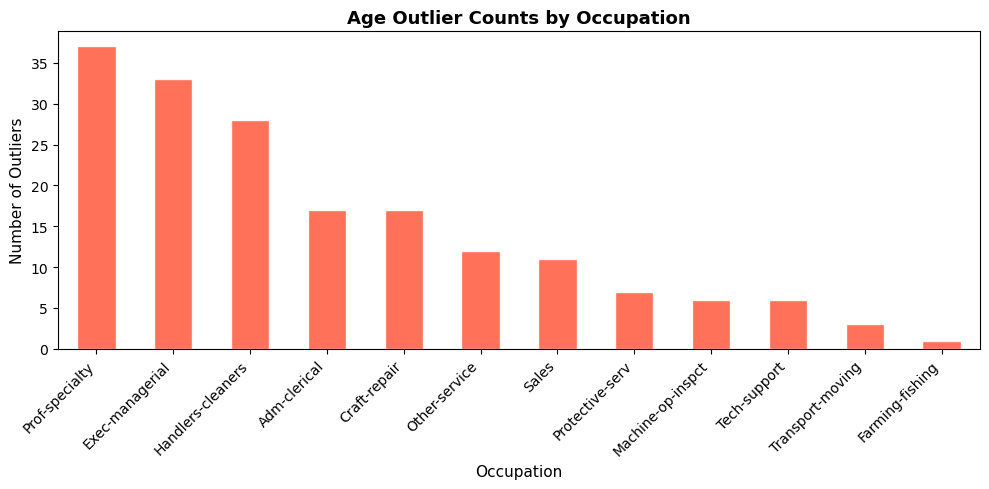

In [37]:
outlier_counts = outliers['occupation'].value_counts()

plt.figure(figsize=(10, 5))
outlier_counts.plot(kind='bar', color='tomato', edgecolor='white', alpha=0.9)
plt.title('Age Outlier Counts by Occupation', fontsize=13, fontweight='bold')
plt.xlabel('Occupation', fontsize=11)
plt.ylabel('Number of Outliers', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Step 15 – Merge Two DataFrames Using a Common Key

In [38]:
# creating a lookup table that maps education labels to approximate years of schooling
edu_lookup = pd.DataFrame({
    'education': ['Bachelors', 'Some-college', 'HS-grad', 'Masters',
                  'Assoc-voc', 'Assoc-acdm', 'Doctorate', 'Prof-school',
                  '10th', '11th', '12th', '9th', '7th-8th', '5th-6th',
                  '1st-4th', 'Preschool'],
    'approx_years': [16, 14, 12, 18, 14, 14, 20, 18, 10, 11, 12, 9, 8, 6, 4, 4]
})

# merging on the 'education' column (common key)
adult_merged = pd.merge(adult_clean, edu_lookup, on='education', how='left')

# drop duplicates just in case
adult_merged.drop_duplicates(inplace=True)

print("Merged DataFrame shape:", adult_merged.shape)
print("\nSample rows with the new approx_years column:")
adult_merged[['age', 'education', 'approx_years', 'occupation']].head(8)


Merged DataFrame shape: (30694, 17)

Sample rows with the new approx_years column:


,age,education,approx_years,occupation
0,39,Bachelors,16,Adm-clerical
1,50,Bachelors,16,Exec-managerial
2,38,HS-grad,12,Handlers-cleaners
3,53,11th,11,Handlers-cleaners
4,28,Bachelors,16,Prof-specialty
5,37,Masters,18,Exec-managerial
6,49,9th,9,Other-service
7,52,HS-grad,12,Exec-managerial


---
## Exercise 3 – Pandas Series Arithmetic

Working with two Series that have partially overlapping indexes.
Pandas handles alignment automatically — where indexes don't match, you get NaN.


In [39]:
import pandas as pd

# Series 1
s1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=['a', 'c', 'd', 'e'])

# Series 2
s2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index=['a', 'c', 'e', 'f', 'g'])

print("Series 1:")
print(s1)
print("\nSeries 2:")
print(s2)


Series 1:
a    7.3
c   -2.5
d    3.4
e    1.5
dtype: float64

Series 2:
a   -2.1
c    3.6
e   -1.5
f    4.0
g    3.1
dtype: float64


### Part C – Add Series 1 and Series 2

In [40]:
# where indexes don't match, pandas fills in NaN for those positions
result_add = s1 + s2
print("Series 1 + Series 2:")
print(result_add)
print("\nNote: d, f, and g result in NaN because they don't exist in both Series.")


Series 1 + Series 2:
a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64

Note: d, f, and g result in NaN because they don't exist in both Series.


### Part D – Subtract Series 1 from Series 2

In [41]:
result_sub = s2 - s1
print("Series 2 - Series 1:")
print(result_sub)
print("\nSame story -- non-overlapping indexes produce NaN.")


Series 2 - Series 1:
a   -9.4
c    6.1
d    NaN
e   -3.0
f    NaN
g    NaN
dtype: float64

Same story -- non-overlapping indexes produce NaN.
